In [1]:
import tensorflow as tf

tf.__version__

'2.15.0'

In [9]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
datas= pd.read_excel("D:\TASK\CP rates\Cogencis data\Tbill364_data.xlsx")
print(datas.shape)
datas.head(5)

(537, 2)


,Date,CutOff_Yield
0,2010-01-13,4.6700
1,2010-01-27,4.6700
2,2010-02-10,4.8791
3,2010-02-24,5.0116
4,2010-03-10,5.1223


### EDA

In [4]:
tbills= pd.read_excel("D:\TASK\CP rates\Cogencis data\Tbill364_data.xlsx", sheet_name='Sheet2')
tbills.set_index(tbills.columns[0], inplace=True)
print(tbills.shape)
tbills.head(3)

(999, 1)


,Yield
Date,
1992-04-28,11.4206
1992-05-13,11.4206
1992-05-27,11.4206


In [5]:
# Using plotly.express
import plotly.express as px

fig = px.line(tbills, x=tbills.index, y="Yield")
fig.update_layout(
    title="364 Days T-Bills Cut-Off Yield Distribution Across Years",
    xaxis=dict(
        tickmode='linear',
        dtick='M12',  # Set tick interval to every 12 months (1 year)
        tickformat="%Y",  # Format ticks as year
        tickangle=-90   # Rotate the Tick Label to Horizontal
    )
)
fig.show()

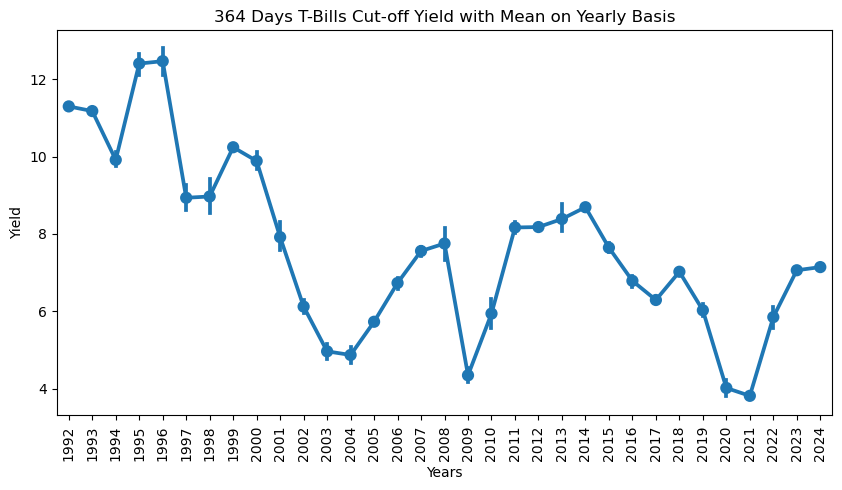

In [10]:
plt.figure(figsize=(10,5))
sns.pointplot(x=tbills.index.year,y=tbills['Yield'])
plt.xticks(rotation=90)
plt.xlabel("Years")
plt.title("364 Days T-Bills Cut-off Yield with Mean on Yearly Basis")
plt.show()

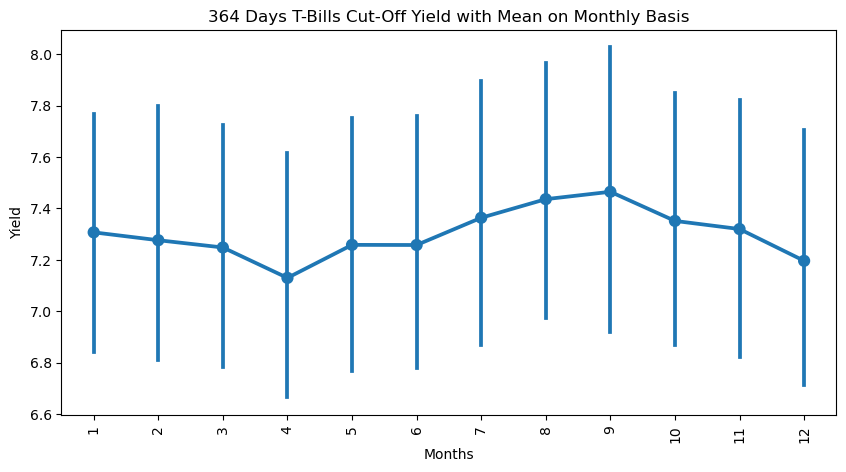

In [11]:
plt.figure(figsize=(10,5))
sns.pointplot(x=tbills.index.month,y=tbills['Yield'])
plt.xticks(rotation=90)
plt.xlabel('Months')
plt.title("364 Days T-Bills Cut-Off Yield with Mean on Monthly Basis")
plt.show()

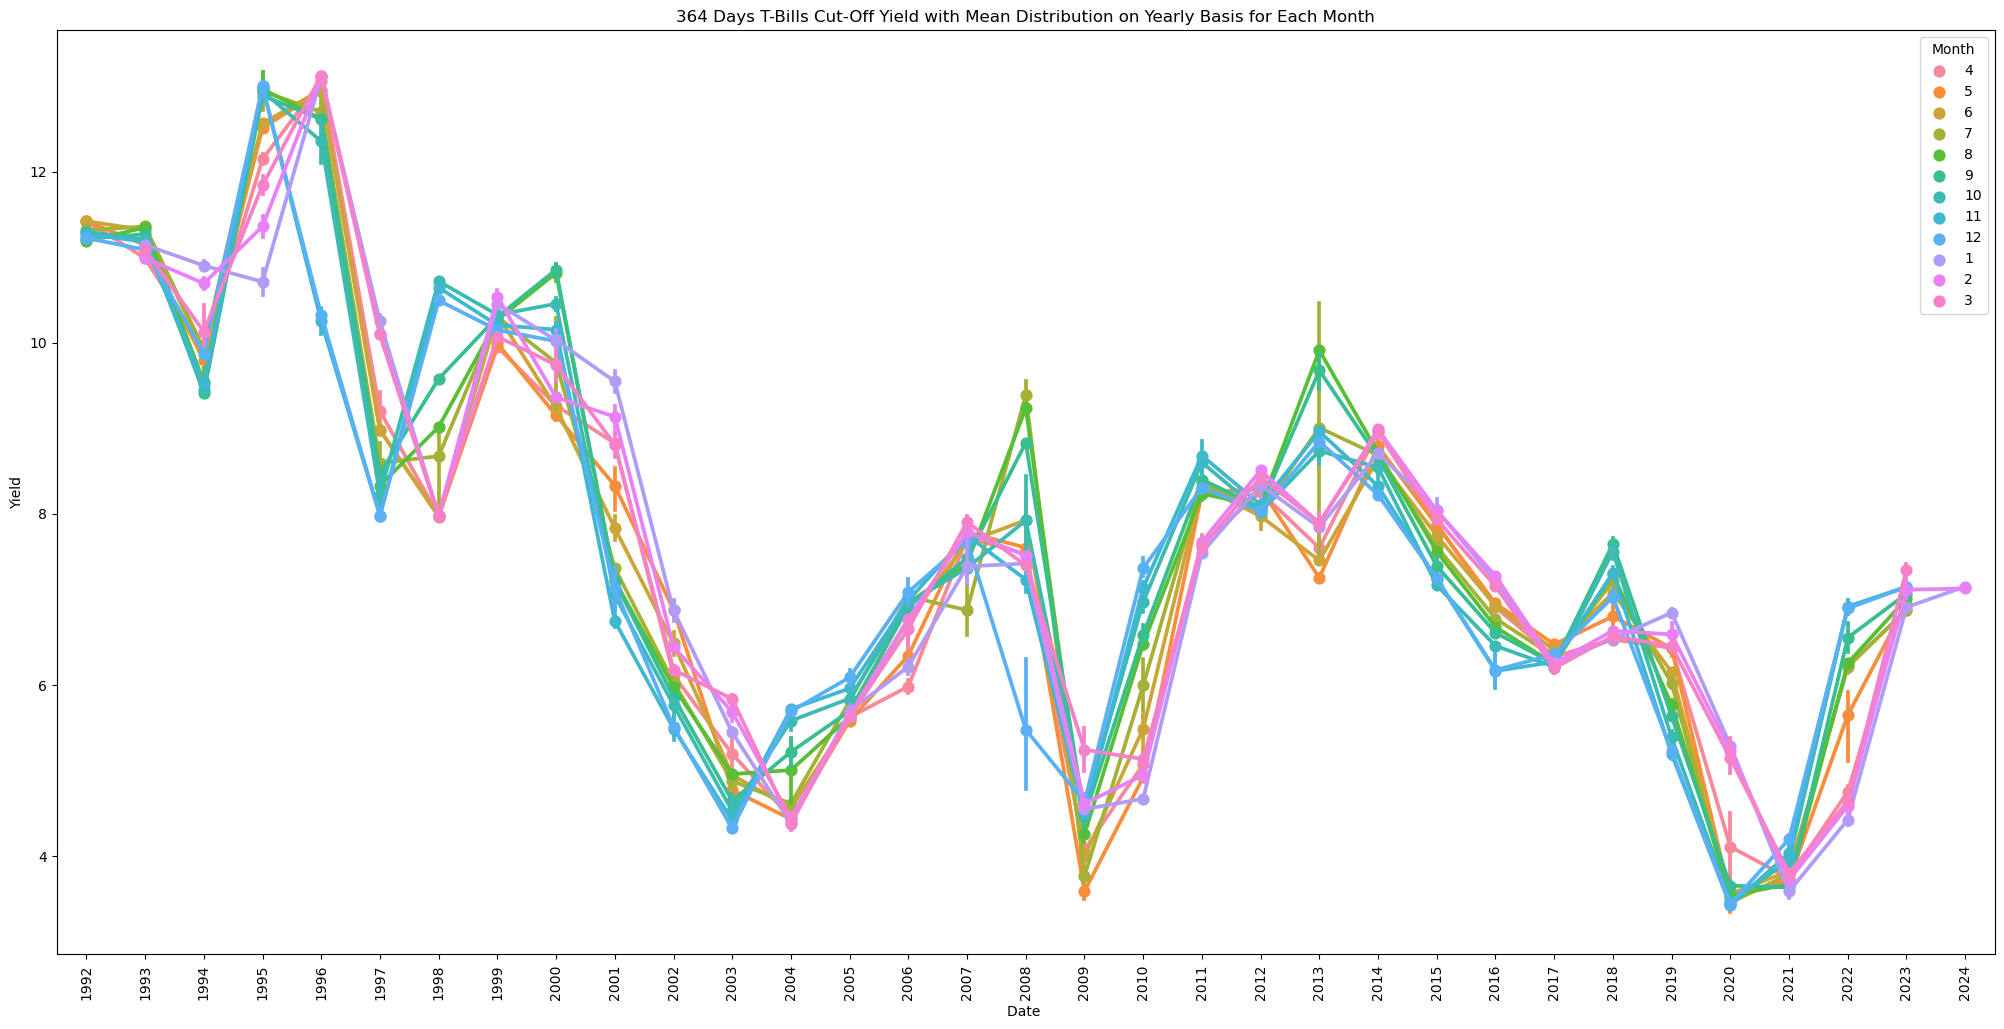

In [12]:
tbills['Month'] = tbills.index.month.astype(str)  # Create a new column for month as strings

#plotting figure 
plt.figure(figsize=(25,12))
sns.pointplot(x=tbills.index.year,y=tbills['Yield'],hue=tbills['Month'], estimator=np.mean)
plt.xticks(rotation=90)
plt.title("364 Days T-Bills Cut-Off Yield with Mean Distribution on Yearly Basis for Each Month")
plt.show()

### Forecast data

In [4]:
# keep Dec, Jan and feb data in seperate dataframe

dfs= datas.tail(18)
dfs.head()

,Date,CutOff_Yield
519,2023-11-01,7.1598
520,2023-11-08,7.1489
521,2023-11-15,7.1297
522,2023-11-22,7.1497
523,2023-11-29,7.1476


### Training data

In [5]:
# Taking the data from Jan-2010 to till Dec-2023 for training

data= datas.iloc[0:-13,:]
data.tail()

,Date,CutOff_Yield
519,2023-11-01,7.1598
520,2023-11-08,7.1489
521,2023-11-15,7.1297
522,2023-11-22,7.1497
523,2023-11-29,7.1476


### Data cleaning

In [6]:
data.index= pd.to_datetime(data['Date'], format="%Y-%m-%d")

In [7]:
data= data.drop('Date', axis=1)
data.head(5)

,CutOff_Yield
Date,
2010-01-13,4.6700
2010-01-27,4.6700
2010-02-10,4.8791
2010-02-24,5.0116
2010-03-10,5.1223


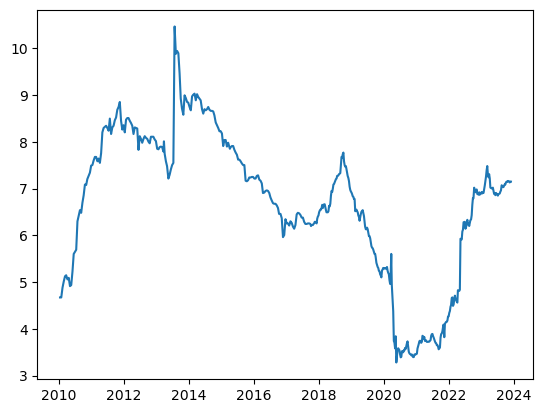

In [8]:
import matplotlib.pyplot as plt
plt.plot(data)

In [9]:
data.head(3)

,CutOff_Yield
Date,
2010-01-13,4.6700
2010-01-27,4.6700
2010-02-10,4.8791


### Train-Test split

In [10]:
train_size = int(len(data)*0.80)
test_size = len(data)-train_size 

print(train_size, test_size)

419 105


In [11]:
df= data.copy()
df= df.reset_index()
df= df.drop(['Date'], axis=1)
df.head(3)

,CutOff_Yield
0,4.6700
1,4.6700
2,4.8791


In [12]:
train_data, test_data= df.iloc[0:train_size,:], df.iloc[train_size:len(df),:]

In [13]:
print(train_data.shape, test_data.shape)

(419, 1) (105, 1)


#### user defined function to create a x and y using window size, example like below
           x            y 
 * [[[1],[2],[3],[4],[5]]]    [6]
 * [[[2],[3],[4],[5],[6]]]    [7]
 * [[[3],[4],[5],[6],[7]]]    [8]

In [14]:
# convert an array of values into a dataset matrix

def data_to_x_y(data, window_size=5):
	x, y = [], []
	for i in range(len(data)-window_size):
		a = data[i:(i+window_size), 0]   ###i=0,1,2,3-----99   100 
		x.append(a)
		y.append(data[i + window_size, 0])
	return np.array(x), np.array(y)


In [15]:
WINDOW_SIZE= 5

#Convert the dataframe into array
train= np.array(train_data)
test= np.array(test_data)

# reshape into X=t,t+1,t+2,t+3 and Y=t+4
train_x, train_y = data_to_x_y(train, window_size= WINDOW_SIZE)
test_x, test_y = data_to_x_y(test, window_size= WINDOW_SIZE)
print(train_x.shape, train_y.shape)

(414, 5) (414,)


In [16]:
print(test_x.shape, test_y.shape)

(100, 5) (100,)


In [17]:
# reshape input to be [samples, time steps, features] which is required for LSTM

train_X = train_x.reshape(train_x.shape[0],train_x.shape[1], 1)
test_X = test_x.reshape(test_x.shape[0],test_x.shape[1], 1)
print(train_X.shape, train_y.shape)

(414, 5, 1) (414,)


### Model Training

In [18]:
LAYERS=[
        tf.keras.layers.Input(shape=(5,1)),
        tf.keras.layers.GRU(units=64),
        tf.keras.layers.Dense(16, activation='LeakyReLU'), 
        #tf.keras.layers.BatchNormalization(),
        #tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1, activation="linear")
]


model= tf.keras.models.Sequential(LAYERS)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 16)                1040      
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 17953 (70.13 KB)
Trainable params: 17953 (70.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
model.compile(loss='mean_squared_error', optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4))

In [20]:
# Setting callbacks for saving the best model which have low losses 

earlystop_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model.h5", monitor='val_loss', save_best_only=True)

callbacks = [earlystop_cb, checkpoint_cb]

# Model train
history = model.fit(train_X, train_y, epochs=100, batch_size=16, validation_data=(test_X, test_y), callbacks=callbacks)


Epoch 1/100

26/26 [==============================] - 3s 30ms/step - loss: 38.6284 - val_loss: 34.1764
Epoch 2/100
26/26 [==============================] - 0s 5ms/step - loss: 34.1752 - val_loss: 30.4611
Epoch 3/100
 1/26 [>.............................] - ETA: 0s - loss: 30.8391

c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


26/26 [==============================] - 0s 4ms/step - loss: 30.4642 - val_loss: 26.7236
Epoch 4/100
26/26 [==============================] - 0s 5ms/step - loss: 26.6226 - val_loss: 22.8619
Epoch 5/100
26/26 [==============================] - 0s 5ms/step - loss: 22.6510 - val_loss: 18.7994
Epoch 6/100
26/26 [==============================] - 0s 5ms/step - loss: 18.4026 - val_loss: 14.4095
Epoch 7/100
26/26 [==============================] - 0s 5ms/step - loss: 13.9457 - val_loss: 10.3031
Epoch 8/100
26/26 [==============================] - 0s 5ms/step - loss: 10.1104 - val_loss: 6.8788
Epoch 9/100
26/26 [==============================] - 0s 4ms/step - loss: 6.9292 - val_loss: 4.0822
Epoch 10/100
26/26 [==============================] - 0s 5ms/step - loss: 4.4788 - val_loss: 2.2011
Epoch 11/100
26/26 [==============================] - 0s 5ms/step - loss: 2.9289 - val_loss: 1.1438
Epoch 12/100
26/26 [==============================] - 0s 5ms/step - loss: 2.0676 - val_loss: 0.6333
Epoch 13

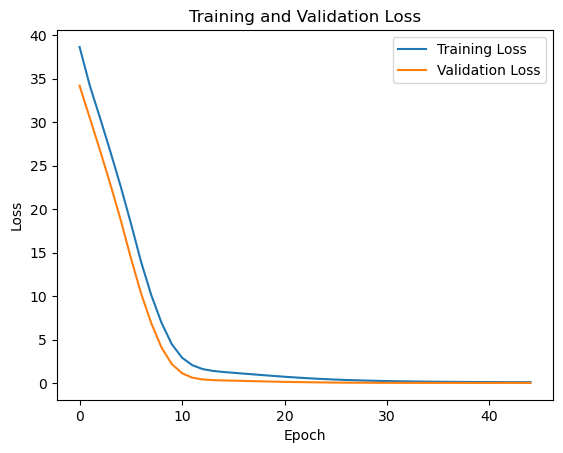

In [21]:
# Accessing the training history

train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plotting the training and validation losses

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### Loading Saved Model

In [22]:
# Load Model
model= "D:\ML_Proj\CP forecasting\model.h5"
Model= tf.keras.models.load_model(model)

### Inferencing

In [23]:
train_pred = Model.predict(train_X)
test_pred = Model.predict(test_X)

4/4 [==============================] - 0s 2ms/step


In [24]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

# RMSE
train_rmse= math.sqrt(mean_squared_error(train_y, train_pred))
train_mae= mean_absolute_error(train_y, train_pred)
#RMSE
test_rmse= math.sqrt(mean_squared_error(test_y, test_pred))
test_mae= mean_absolute_error(test_y, test_pred)
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

print(f"Train MAE: {train_mae}")
print(f"Test MAE: {test_mae}")



Train RMSE: 0.35981094664637625
Test RMSE: 0.17347419973563724
Train MAE: 0.2398737326046119
Test MAE: 0.1188492039642334


In [25]:
dfrs= pd.DataFrame(test_pred, columns=['Predictions'])
dfrs['Actuals']= pd.DataFrame(test_y)
dfrs.head(3)

,Predictions,Actuals
0,4.286821,4.3400
1,4.335938,4.3800
2,4.390542,4.4727


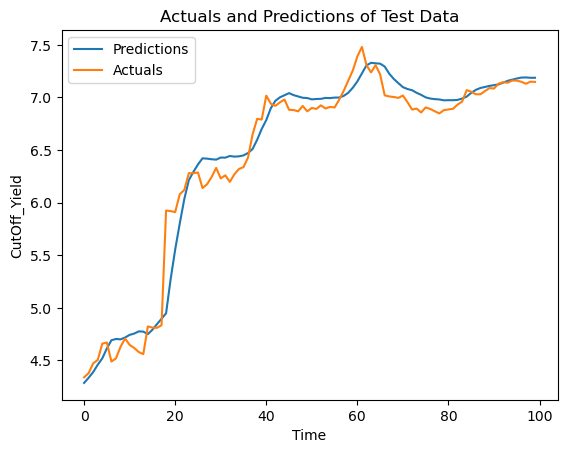

In [26]:
import matplotlib.pyplot as plt
plt.plot()
plt.plot()

# Plotting the training and validation losses

plt.plot(dfrs['Predictions'], label='Predictions')
plt.plot(dfrs['Actuals'], label='Actuals')
plt.xlabel('Time')
plt.ylabel('CutOff_Yield')
plt.title('Actuals and Predictions of Test Data')
plt.legend()
plt.show()

### Training on whole dataset

In [27]:
WINDOW_SIZE= 5

#Convert the dataframe into array
dataf= np.array(df)

# reshape into X=t,t+1,t+2,t+3 and Y=t+4
x, y = data_to_x_y(dataf, window_size= WINDOW_SIZE)

# reshape input into LSTM format - [samples, time steps, features]
X = x.reshape(x.shape[0],x.shape[1], 1)
print(X.shape, y.shape)

(519, 5, 1) (519,)


In [28]:
Model.compile(loss='mean_squared_error', optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4))

In [29]:
# Model train

earlystop_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model1.h5", monitor='val_loss', save_best_only=True)

callbacks = [earlystop_cb, checkpoint_cb]

History = Model.fit(X, y, epochs=100, batch_size=16, validation_split=0.10, callbacks=callbacks) #validation_split=0.10


Epoch 1/100
30/30 [==============================] - 3s 24ms/step - loss: 0.1106 - val_loss: 0.0130
Epoch 2/100
30/30 [==============================] - 0s 4ms/step - loss: 0.0977 - val_loss: 0.0127
Epoch 3/100
24/30 [=======================>......] - ETA: 0s - loss: 0.0948

c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


30/30 [==============================] - 0s 4ms/step - loss: 0.0893 - val_loss: 0.0104
Epoch 4/100
30/30 [==============================] - 0s 3ms/step - loss: 0.0876 - val_loss: 0.0122
Epoch 5/100
30/30 [==============================] - 0s 3ms/step - loss: 0.0789 - val_loss: 0.0152
Epoch 6/100
30/30 [==============================] - 0s 3ms/step - loss: 0.0758 - val_loss: 0.0169
Epoch 7/100
30/30 [==============================] - 0s 3ms/step - loss: 0.0729 - val_loss: 0.0127
Epoch 8/100
30/30 [==============================] - 0s 4ms/step - loss: 0.0694 - val_loss: 0.0102
Epoch 9/100
30/30 [==============================] - 0s 4ms/step - loss: 0.0680 - val_loss: 0.0148
Epoch 10/100
30/30 [==============================] - 0s 3ms/step - loss: 0.0648 - val_loss: 0.0122
Epoch 11/100
30/30 [==============================] - 0s 4ms/step - loss: 0.0625 - val_loss: 0.0083
Epoch 12/100
30/30 [==============================] - 0s 4ms/step - loss: 0.0626 - val_loss: 0.0078
Epoch 13/100
30/30 

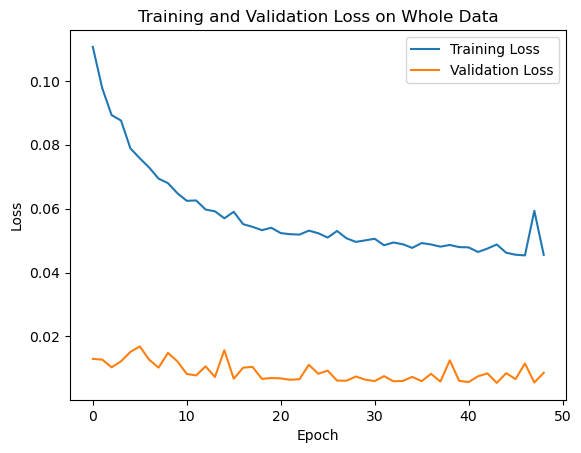

In [30]:
# Accessing the training history

train_loss = History.history['loss']
val_loss = History.history['val_loss']

# Plotting the training and validation losses

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss on Whole Data')
plt.legend()
plt.show()

### Inferencing on future data

In [31]:
WINDOW_SIZE= 5

#Convert the dataframe into array
dfs= dfs[['CutOff_Yield']]
dtfr= np.array(dfs)

# reshape into X=t,t+1,t+2,t+3 and Y=t+4
s, t = data_to_x_y(dtfr, window_size= WINDOW_SIZE)

# reshape input into LSTM format - [samples, time steps, features]
S = s.reshape(s.shape[0],s.shape[1], 1)
print(S.shape, t.shape)

(13, 5, 1) (13,)


In [32]:
# Load Model
model= "D:\ML_Proj\CP forecasting\model1.h5"
lstm_model= tf.keras.models.load_model(model)

In [33]:
pred = lstm_model.predict(S)

1/1 [==============================] - 1s 501ms/step


In [34]:
index= ["06-Dec","13-Dec","20-Dec","27-Dec","03-Jan","10-Jan","17-Jan","24-Jan","31-Jan","07-Feb","14-Feb","21-Feb","28-Feb"]
act = pd.DataFrame(t, columns=['Actuals'], index=index)
preds = pd.DataFrame(pred, columns=['Forecasted'], index=index)
output= pd.concat([act, preds], axis=1)
output

,Actuals,Forecasted
06-Dec,7.1585,7.147510
13-Dec,7.1899,7.155855
20-Dec,7.1101,7.176806
27-Dec,7.1300,7.148193
03-Jan,7.1257,7.137384
10-Jan,7.1486,7.127958
17-Jan,7.1540,7.136619
24-Jan,7.1700,7.152088
31-Jan,7.1541,7.164622
07-Feb,7.1138,7.164176


In [35]:
rmse= math.sqrt(mean_squared_error(output['Actuals'], output['Forecasted']))

mae= mean_absolute_error(output['Actuals'], output['Forecasted'])

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

RMSE: 0.02801018068266428
MAE: 0.021914173184908233


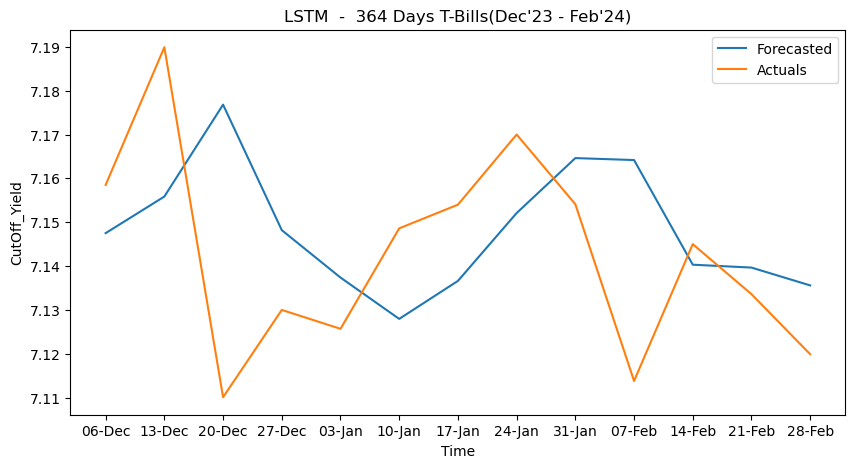

In [36]:
import matplotlib.pyplot as plt
#plt.plot()

# Plotting the training and validation losses
plt.figure(figsize=(10,5))
plt.plot(output['Forecasted'], label='Forecasted')
plt.plot(output['Actuals'], label='Actuals')
plt.xlabel('Time')
plt.ylabel('CutOff_Yield')
plt.title("LSTM  -  364 Days T-Bills(Dec'23 - Feb'24)")
plt.legend()
plt.show()